In [1]:
'''
performance on stock predictions
''' 

'\nperformance on stock predictions\n'

In [2]:
# pip install prophet

In [3]:
from prophet import Prophet

In [4]:
from prophet.diagnostics import cross_validation

In [5]:
from prophet.diagnostics import performance_metrics

In [6]:
from prophet.plot import plot_cross_validation_metric

In [7]:
from prophet.plot import add_changepoints_to_plot

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

### understanding data

In [10]:
df = pd.read_csv(r'sp500sub.csv', index_col = 'Date', parse_dates = True)

In [11]:
goog = df[df['Name']=='GOOG'][['Close']].copy()

In [12]:
goog.head()

,Close
Date,
2010-01-04,312.204773
2010-01-05,310.829926
2010-01-06,302.994293
2010-01-07,295.940735
2010-01-08,299.885956


In [13]:
goog.columns = ['y']

In [14]:
goog['ds'] = goog.index

11:00:33 - cmdstanpy - INFO - Chain [1] start processing
11:00:40 - cmdstanpy - INFO - Chain [1] done processing


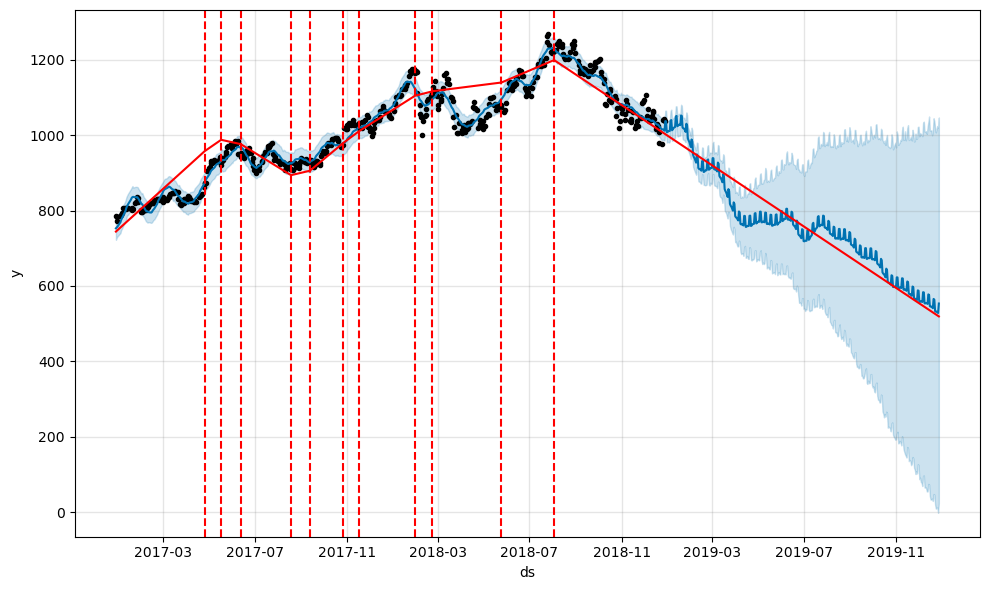

In [15]:
m = Prophet()
m.fit(goog.iloc[-252*2:]) # not using the entire time series to build the model
future = m.make_future_dataframe(periods = 365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [24]:
goog.iloc[-252*2:].tail()

,y,ds
Date,,
2018-12-21,979.539978,2018-12-21
2018-12-24,976.219971,2018-12-24
2018-12-26,1039.459961,2018-12-26
2018-12-27,1043.880005,2018-12-27
2018-12-28,1037.079956,2018-12-28


In [26]:
''' 
not really a great fit
After the data ends, 28th Dec 2021 in goog.iloc[-252*2:], 
there appears to be tiny little hairs which suggests high frequency seasonality in the forecast, which is wierd since stocks shouldnt look like this.
daily seasonality will not be there since data at daily level but weeekly seasonality is intact - this weekly seasonality is the little hairs.
Also prophet only capable of linear and logistic trends - thus model assumes the stock prices go down in the future which might not be sensible
'''

' \nnot really a great fit\nAfter the data ends, 28th Dec 2021 in goog.iloc[-252*2:], \nthere appears to be tiny little hairs which suggests high frequency seasonality in the forecast, which is wierd since stocks shouldnt look like this.\ndaily seasonality will not be there since data at daily level but weeekly seasonality is intact - this weekly seasonality is the little hairs.\nAlso prophet only capable of linear and logistic trends - thus model assumes the stock prices go down in the future which might not be sensible\n'

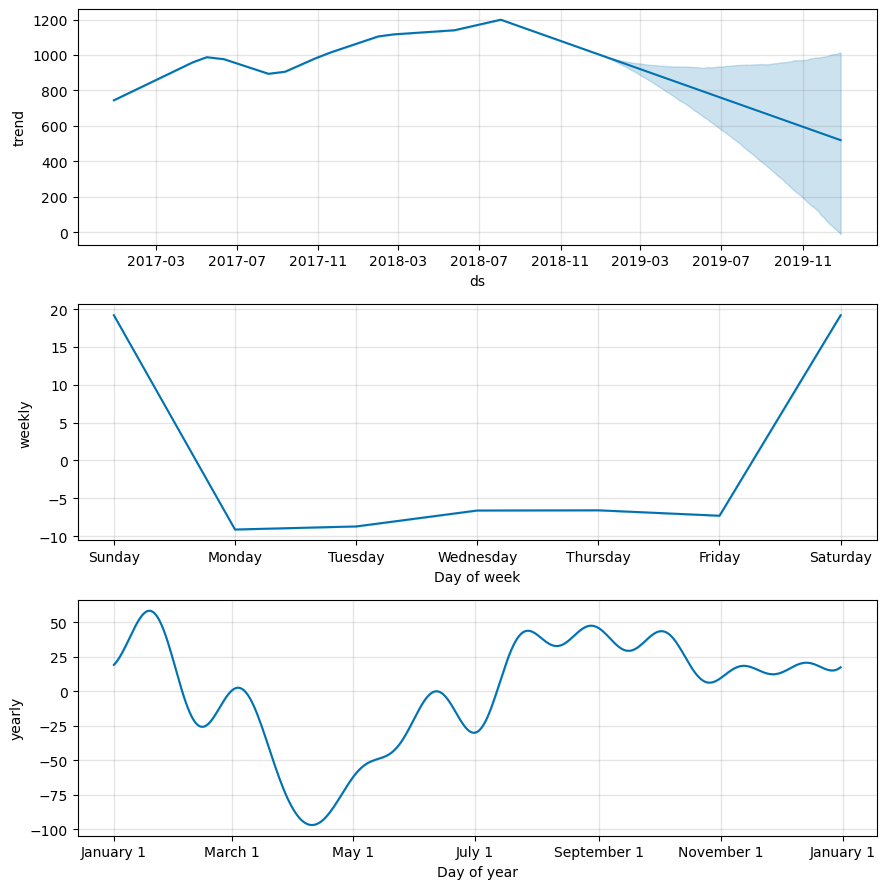

In [27]:
m.plot_components(forecast);

In [28]:
''' 
the confidence interval in the trends gets big pretty rapidly suggesting model not really sure of this trend
weekly seasonality detected which makes no sense since it shows spike in weekends which doesnt make sense since markets not open on weekends
yearly seasonality detected which might be true but magnitude is very less compared to the trend - which is miniscule
'''


' \nthe confidence interval in the trends gets big pretty rapidly suggesting model not really sure of this trend\nweekly seasonality detected which makes no sense since it shows spike in weekends which doesnt make sense since markets not open on weekends\nyearly seasonality detected which might be true but magnitude is very less compared to the trend - which is miniscule\n'

11:14:05 - cmdstanpy - INFO - Chain [1] start processing
11:14:08 - cmdstanpy - INFO - Chain [1] done processing


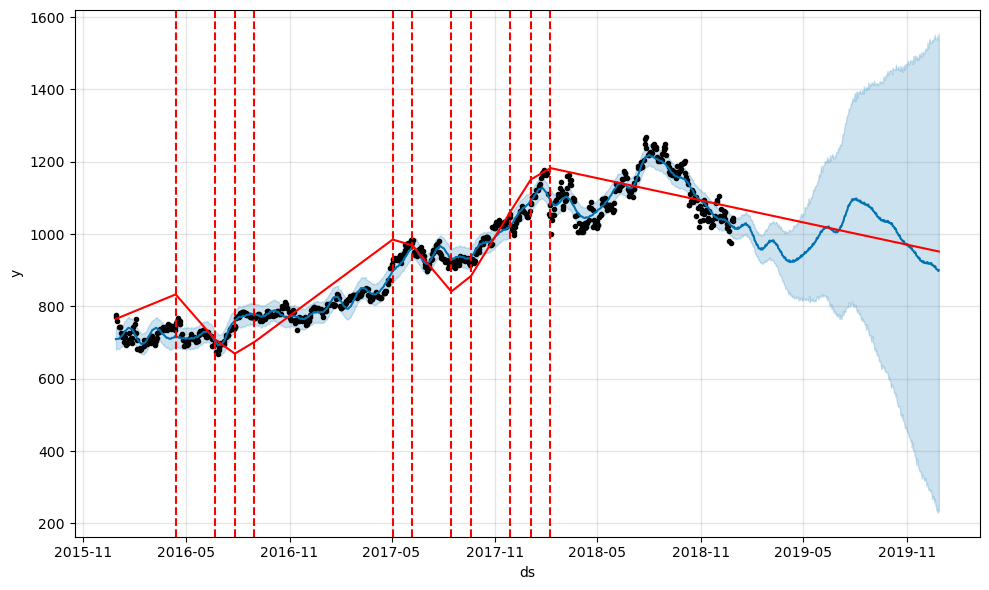

In [30]:
#BAD !! FROM BLOG ARTICLES
m = Prophet(daily_seasonality = True)
m.fit(goog.iloc[-252*3:])
future = m.make_future_dataframe (periods = 365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [32]:
''' 
setting daily seasonality to True - makes 0 sense since data at a daily level - for daily seasonality, sub daily (a level lower than daily) is required
getting smoother patterns but based on false presumption - tiny hairs appear in forecast representing daily level'''




' \nsetting daily seasonality to True - makes 0 sense since data at a daily level - for daily seasonality, sub daily (a level lower than daily) is required\ngetting smoother patterns but based on false presumption - tiny hairs appear in forecast representing daily level'

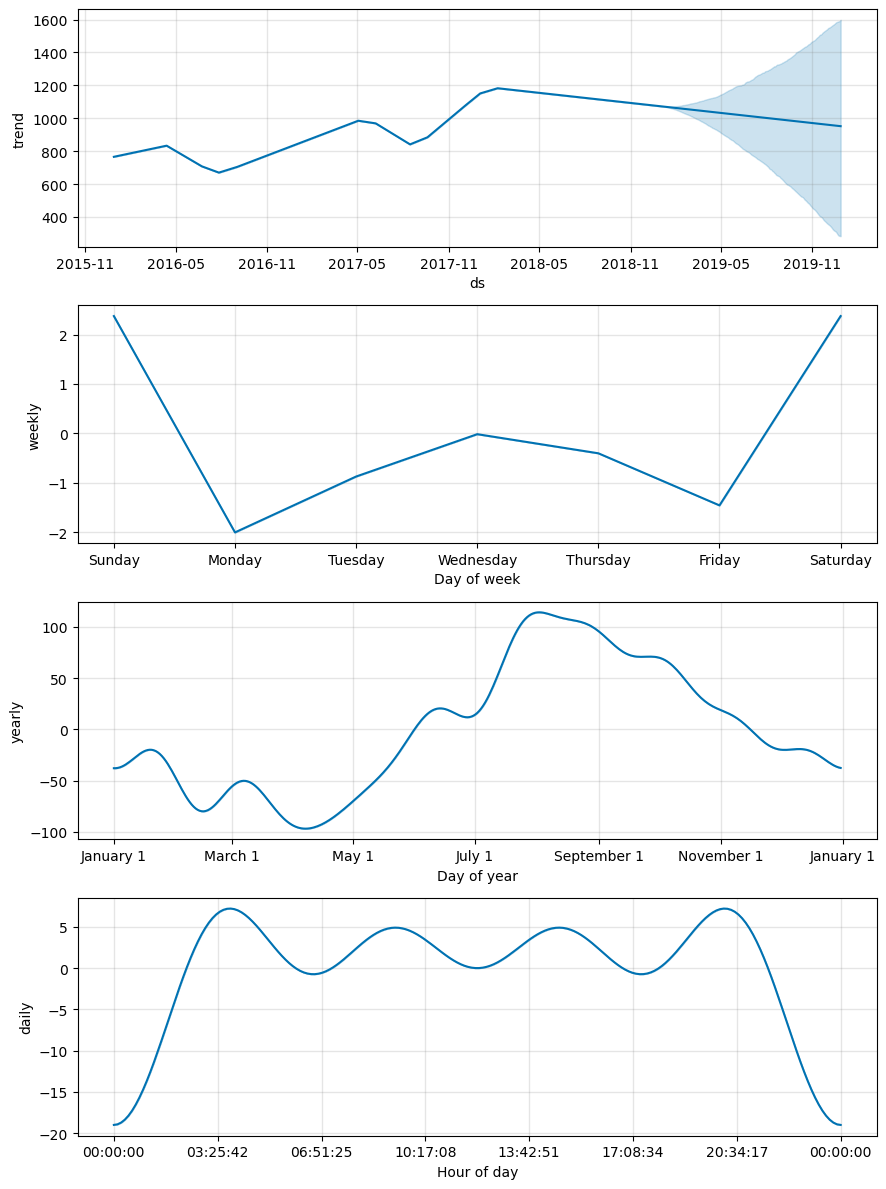

In [33]:
m.plot_components(forecast);

In [34]:
''' look at daily seasonal - impossible for model to do something like this - hourly data doesnt exist at all'''

' look at daily seasonal - impossible for model to do something like this - hourly data doesnt exist at all'

11:19:50 - cmdstanpy - INFO - Chain [1] start processing
11:19:51 - cmdstanpy - INFO - Chain [1] done processing


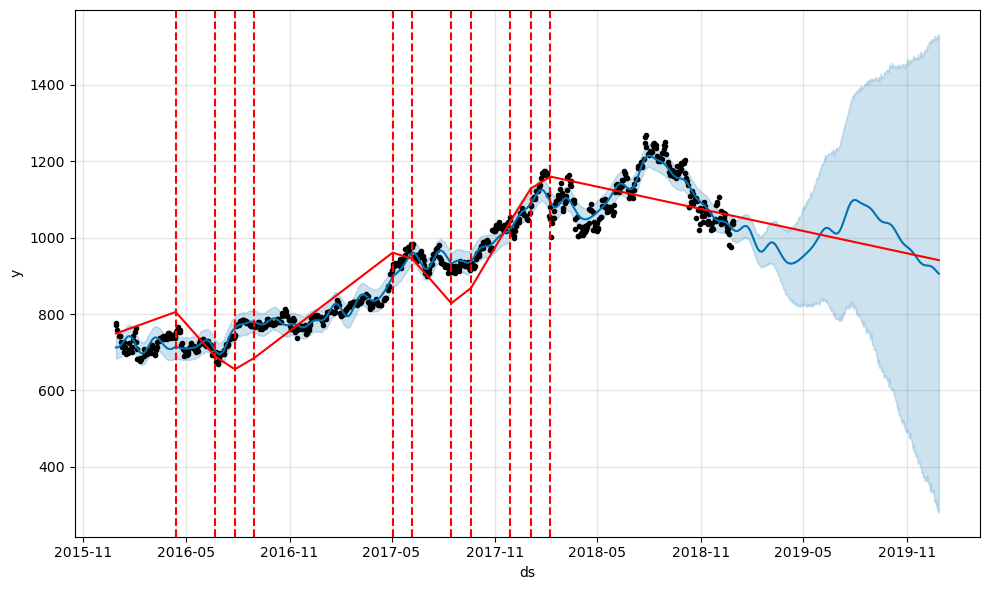

In [37]:
m = Prophet(weekly_seasonality = False) # setting to false - will help us identify any false seasonal patterns
m.fit(goog.iloc[-252*3:])
future = m.make_future_dataframe (periods = 365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [38]:
''' no small hairs'''

' no small hairs'

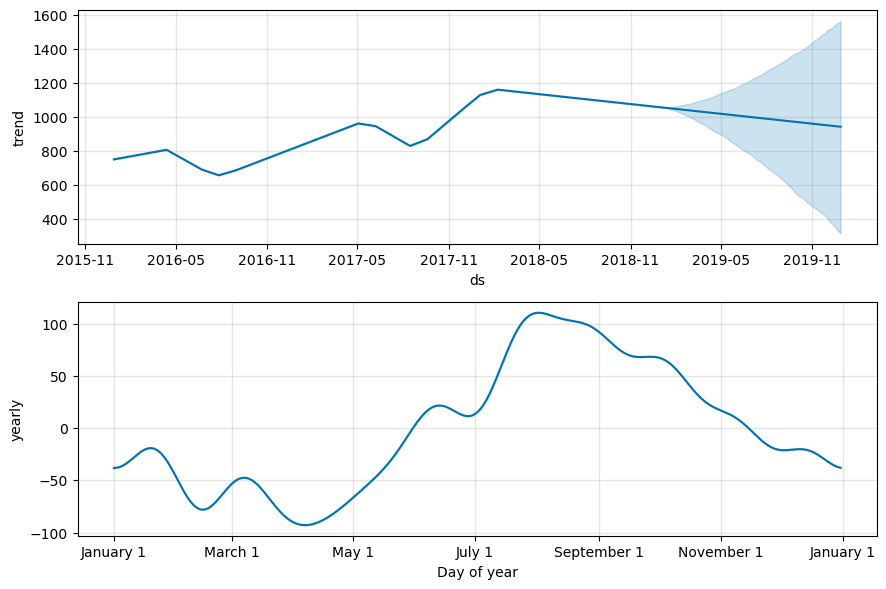

In [39]:
m.plot_components(forecast);

### Cross Validation
##### checking if model can beat the NAIVE forecast (last day prediction copied over to the next day

In [40]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

In [41]:
m = Prophet(weekly_seasonality = False) # setting to false - will help us identify any false seasonal patterns
m.fit(goog.iloc[-252*2:])
# future = m.make_future_dataframe (periods = 365)
# forecast = m.predict(future)
# fig = m.plot(forecast);
# a = add_changepoints_to_plot(fig.gca(), m, forecast)

11:24:04 - cmdstanpy - INFO - Chain [1] start processing
11:24:04 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
# try period = 15, horizon = 30 - result remained the same
# try period = 30, horizon = 60 - result remained the same
df_cv = cross_validation(
    m,
    initial = '365 days',
    period = '5 days',
    horizon = '5 days')

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/73 [00:00<?, ?it/s]

11:25:26 - cmdstanpy - INFO - Chain [1] start processing
11:25:26 - cmdstanpy - INFO - Chain [1] done processing
11:25:27 - cmdstanpy - INFO - Chain [1] start processing
11:25:27 - cmdstanpy - INFO - Chain [1] done processing
11:25:27 - cmdstanpy - INFO - Chain [1] start processing
11:25:27 - cmdstanpy - INFO - Chain [1] done processing
11:25:27 - cmdstanpy - INFO - Chain [1] start processing
11:25:27 - cmdstanpy - INFO - Chain [1] done processing
11:25:28 - cmdstanpy - INFO - Chain [1] start processing
11:25:28 - cmdstanpy - INFO - Chain [1] done processing
11:25:28 - cmdstanpy - INFO - Chain [1] start processing
11:25:28 - cmdstanpy - INFO - Chain [1] done processing
11:25:29 - cmdstanpy - INFO - Chain [1] start processing
11:25:29 - cmdstanpy - INFO - Chain [1] done processing
11:25:29 - cmdstanpy - INFO - Chain [1] start processing
11:25:29 - cmdstanpy - INFO - Chain [1] done processing
11:25:29 - cmdstanpy - INFO - Chain [1] start processing
11:25:30 - cmdstanpy - INFO - Chain [1]

In [44]:
''' since horizon = period, there will be no ds for which there are multiple predictions for different cut off dates'''

' since horizon = period, there will be no ds for which there are multiple predictions for different cut off dates'

In [45]:
df_cv.tail(20)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
231,2018-11-29,1017.152660,992.782317,1044.815545,1088.300049,2018-11-28
232,2018-11-30,1014.762583,987.230343,1040.031072,1094.430054,2018-11-28
233,2018-12-03,1009.058200,983.995560,1036.278636,1106.430054,2018-11-28
234,2018-12-04,1041.414824,1015.547272,1068.356941,1050.819946,2018-12-03
235,2018-12-06,1040.879559,1014.177155,1066.122087,1068.729980,2018-12-03
236,2018-12-07,1040.687930,1013.836907,1067.237095,1036.579956,2018-12-03
237,2018-12-10,1043.325746,1015.583938,1070.107696,1039.550049,2018-12-08
238,2018-12-11,1043.052473,1017.043832,1070.995021,1051.750000,2018-12-08
239,2018-12-12,1042.676024,1016.314570,1067.199078,1063.680054,2018-12-08
240,2018-12-13,1042.178613,1014.055965,1069.497121,1061.900024,2018-12-08


In [46]:
df_cv.shape

(251, 6)

In [47]:
naive = df_cv[['ds','yhat','y','cutoff']].copy()

In [54]:
# forecast for ds should come from its cutoff date in naive forecast
naive_storage = np.zeros(naive.shape[0])
one_day = pd.Timedelta(1, 'day')

for i, row in naive.iterrows():
    cutoff = row['cutoff'] # grab cutoff date 

    while cutoff not in goog.index: # check if the cut off date exist in the goog dataframe, if it doesmnt grab the previous cutoff date
        cutoff = cutoff - one_day

    naive_storage[i] = goog.loc[cutoff]['y'] # grab the price on the cutoff date and use that as prediction

naive['yhat'] = naive_storage # overwrite with the calculated stock prices above
    

In [55]:
pm = performance_metrics(df_cv)
pm.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,1474.591324,38.400408,30.446911,0.027459,0.021799,0.027195,0.423077
1,2 days,1730.840406,41.603370,32.795314,0.029606,0.022514,0.029324,0.408163
2,3 days,1758.957673,41.939929,34.853364,0.031400,0.027692,0.031197,0.387755
3,4 days,1958.263454,44.252271,35.383907,0.031856,0.026934,0.031675,0.428571
4,5 days,2545.912256,50.457034,40.887485,0.037017,0.033297,0.036785,0.326923


In [56]:
pm['smape'].mean()

0.031235315787641726

In [57]:
naive_metrics = performance_metrics(naive)
naive_metrics['smape'].mean()

0.020548255026446992

In [60]:
''' unable to beat the naive metrics '''

' unable to beat the naive metrics '

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


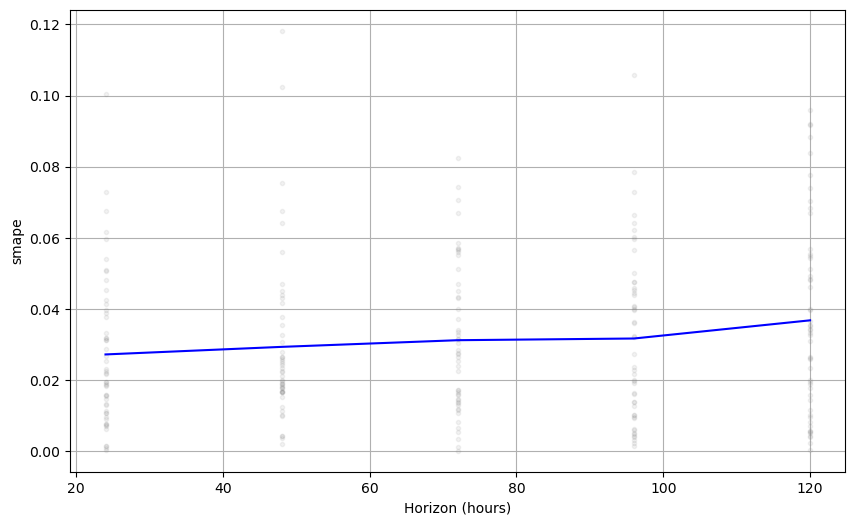

In [59]:
plot_cross_validation_metric(df_cv, metric = 'smape');

In [61]:
''' forecast error tends to grow over time'''

' forecast error tends to grow over time'

### cross validation with Logged Data

In [63]:
log_goog = goog.copy()
log_goog['y'] = np.log(goog['y'])

In [67]:
m = Prophet(weekly_seasonality = False) # setting to false - will help us identify any false seasonal patterns
m.fit(log_goog.iloc[-252*2:])

11:48:58 - cmdstanpy - INFO - Chain [1] start processing
11:48:58 - cmdstanpy - INFO - Chain [1] done processing


In [68]:
# try period = 15, horizon = 30 - result remained the same
# try period = 30, horizon = 60 - result remained the same
df_cv = cross_validation(
    m,
    initial = '365 days',
    period = '30 days',
    horizon = '60 days')

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/11 [00:00<?, ?it/s]

11:50:02 - cmdstanpy - INFO - Chain [1] start processing
11:50:03 - cmdstanpy - INFO - Chain [1] done processing
11:50:03 - cmdstanpy - INFO - Chain [1] start processing
11:50:03 - cmdstanpy - INFO - Chain [1] done processing
11:50:03 - cmdstanpy - INFO - Chain [1] start processing
11:50:04 - cmdstanpy - INFO - Chain [1] done processing
11:50:04 - cmdstanpy - INFO - Chain [1] start processing
11:50:04 - cmdstanpy - INFO - Chain [1] done processing
11:50:04 - cmdstanpy - INFO - Chain [1] start processing
11:50:05 - cmdstanpy - INFO - Chain [1] done processing
11:50:05 - cmdstanpy - INFO - Chain [1] start processing
11:50:05 - cmdstanpy - INFO - Chain [1] done processing
11:50:05 - cmdstanpy - INFO - Chain [1] start processing
11:50:06 - cmdstanpy - INFO - Chain [1] done processing
11:50:06 - cmdstanpy - INFO - Chain [1] start processing
11:50:07 - cmdstanpy - INFO - Chain [1] done processing
11:50:07 - cmdstanpy - INFO - Chain [1] start processing
11:50:07 - cmdstanpy - INFO - Chain [1]

In [71]:
df_cv.to_clipboard()

In [72]:
pm = performance_metrics(df_cv)
pm.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,6 days,0.001694,0.041164,0.029247,0.004174,0.002971,0.004170,0.511111
1,7 days,0.002551,0.050508,0.035854,0.005123,0.003591,0.005114,0.444444
2,8 days,0.003286,0.057321,0.042874,0.006126,0.005839,0.006113,0.355556
3,9 days,0.003528,0.059397,0.047013,0.006713,0.006506,0.006703,0.273016
4,10 days,0.003577,0.059812,0.049565,0.007074,0.006889,0.007069,0.187302


In [73]:
pm['smape'].mean()

0.014518189285076689

In [74]:
naive = df_cv[['ds','yhat','y','cutoff']].copy()

In [77]:
# forecast for ds should come from its cutoff date in naive forecast
naive_storage = np.zeros(naive.shape[0])
one_day = pd.Timedelta(1, 'day')

for i, row in naive.iterrows():
    cutoff = row['cutoff'] # grab cutoff date 

    while cutoff not in log_goog.index: # check if the cut off date exist in the goog dataframe, if it doesmnt grab the previous cutoff date
        cutoff = cutoff - one_day

    naive_storage[i] = log_goog.loc[cutoff]['y'] # grab the price on the cutoff date and use that as prediction

naive['yhat'] = naive_storage # overwrite with the calculated stock prices above

In [78]:
naive_metrics = performance_metrics(naive)
naive_metrics['smape'].mean()


0.008361150811971313

In [81]:
''' naive forecast wins'''

' naive forecast wins'

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


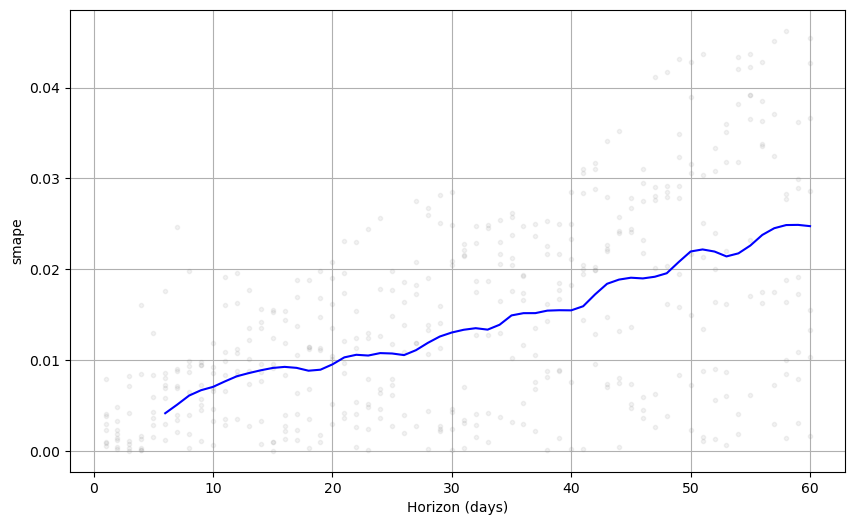

In [86]:
plot_cross_validation_metric(df_cv, metric = 'smape');

In [84]:
'''forecast error iincreases'''

'forecast error iincreases'